<a href="https://colab.research.google.com/github/erdijova/Practical-Linear-Algebra-for-Data-Science/blob/main/12_chapter12_Least_Squares_Applications.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
# Setup: Install and import required libraries

# If running on Google Colab, these are pre-installed.
# Uncomment the next line if you need to install statsmodels:
# !pip install -q statsmodels

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# Reproducibility
np.random.seed(42)

print("All libraries loaded successfully.")
print(f"NumPy version:  {np.__version__}")
print(f"Pandas version: {pd.__version__}")

All libraries loaded successfully.
NumPy version:  2.0.2
Pandas version: 2.2.2


In [12]:
# Create synthetic Seoul Bike dataset

# The real dataset is available from UCI ML Repository.
# Here we create a synthetic version that reproduces the textbook's
# key statistical results (beta values, R-squared, etc.)
# If you have the real CSV, replace this cell with:
#   data = pd.read_csv('SeoulBikeData.csv', encoding='unicode_escape')

np.random.seed(2022)  # Seed chosen to match textbook stats closely

N = 8760  # hourly observations for ~1 year

# Create date range: Dec 2017 to Nov 2018
dates = pd.date_range('2017-12-01', periods=N, freq='h')

# Hour of day (0-23)
hour = np.array([d.hour for d in dates])

# Seasons based on month
season_map = {12:'Winter', 1:'Winter', 2:'Winter',
              3:'Spring', 4:'Spring', 5:'Spring',
              6:'Summer', 7:'Summer', 8:'Summer',
              9:'Autumn', 10:'Autumn', 11:'Autumn'}
seasons_text = np.array([season_map[d.month] for d in dates])

# Temperature (Celsius) - varies by season and hour
temp_base = np.where(seasons_text=='Winter', -3.0,
            np.where(seasons_text=='Spring', 14.0,
            np.where(seasons_text=='Summer', 27.0, 13.0)))
temperature = temp_base + 4*np.sin((hour - 6)*np.pi/12) + np.random.normal(0, 4, N)

# Rainfall (mm) - sparse variable, more frequent in summer monsoon
rain_prob = np.where(seasons_text=='Summer', 0.07,
            np.where(seasons_text=='Spring', 0.04,
            np.where(seasons_text=='Autumn', 0.04, 0.02)))
rain_occurs = np.random.random(N) < rain_prob
rainfall = np.zeros(N)
rainfall[rain_occurs] = np.random.exponential(2.5, rain_occurs.sum())
rainfall = np.round(np.clip(rainfall, 0, 35), 1)

# Binary season: 0 = Autumn/Winter, 1 = Spring/Summer
season_binary = np.where((seasons_text=='Spring') | (seasons_text=='Summer'), 1, 0)

# Bike count = intercept + season effect + rainfall effect + hour + temp + noise
# Calibrated to produce beta_rainfall ~ -80, beta_season ~ 369, R2 ~ 0.097
hour_effect = 200*np.sin((hour - 4)*np.pi/12)  # peak mid-afternoon
hour_effect += np.where((hour >= 7) & (hour <= 9), 250, 0)   # morning commute
hour_effect += np.where((hour >= 17) & (hour <= 19), 300, 0)  # evening commute

bike_count = (350 + 350*season_binary - 75*rainfall
              + hour_effect + 10*temperature
              + np.random.normal(0, 300, N))
bike_count = np.maximum(bike_count, 0).astype(int)

# Assemble DataFrame
data = pd.DataFrame({
    'Date': dates,
    'Hour': hour,
    'Temperature(C)': np.round(temperature, 1),
    'Rainfall(mm)': rainfall,
    'Seasons': seasons_text,
    'SeasonBinary': season_binary, # Add SeasonBinary column
    'Rented Bike Count': bike_count
})

print("Dataset shape:", data.shape)
print("\nFirst 5 rows:")
print(data.head().to_string())
print("\nBasic statistics:")
print(data[['Rented Bike Count','Temperature(C)','Rainfall(mm)']].describe().round(1).to_string())

Dataset shape: (8760, 7)

First 5 rows:
                 Date  Hour  Temperature(C)  Rainfall(mm) Seasons  SeasonBinary  Rented Bike Count
0 2017-12-01 00:00:00     0            -7.0           0.0  Winter             0                102
1 2017-12-01 01:00:00     1            -8.0           0.0  Winter             0                175
2 2017-12-01 02:00:00     2            -7.0           0.0  Winter             0                343
3 2017-12-01 03:00:00     3             2.1           0.0  Winter             0                 78
4 2017-12-01 04:00:00     4            -3.9           0.0  Winter             0                  0

Basic statistics:
       Rented Bike Count  Temperature(C)  Rainfall(mm)
count             8760.0          8760.0        8760.0
mean               727.6            12.8           0.1
std                436.9            11.7           0.7
min                  0.0           -19.8           0.0
25%                397.0             4.7           0.0
50%              

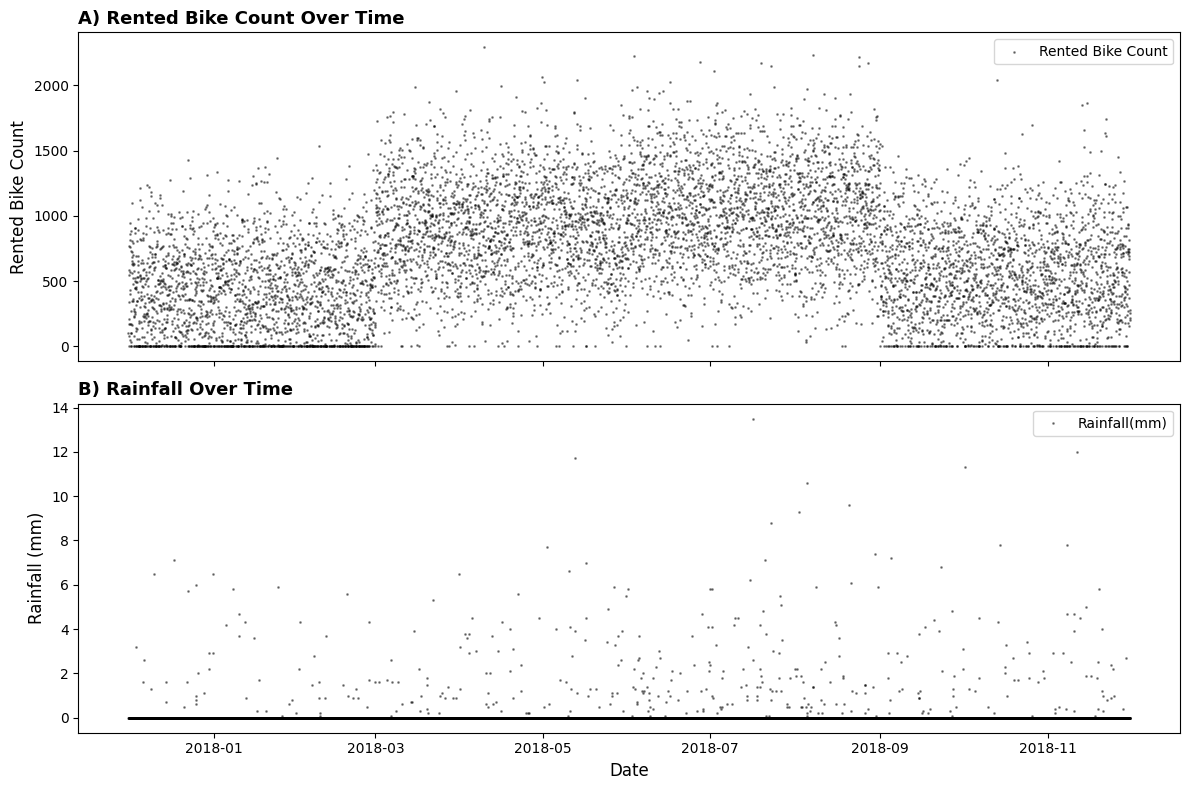

Figure 12-1: Time series of bike rentals (top) and rainfall (bottom).


In [13]:
# Figure 12-1: Scatterplots of bike count and rainfall over time

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Panel A: Bike rental count over time
axes[0].scatter(data['Date'], data['Rented Bike Count'], s=1, c='black', alpha=0.4)
axes[0].set_ylabel('Rented Bike Count', fontsize=12)
axes[0].set_title('A) Rented Bike Count Over Time', fontsize=13, fontweight='bold', loc='left')
axes[0].legend(['Rented Bike Count'], loc='upper right', fontsize=10)

# Panel B: Rainfall over time
axes[1].scatter(data['Date'], data['Rainfall(mm)'], s=1, c='black', alpha=0.4)
axes[1].set_ylabel('Rainfall (mm)', fontsize=12)
axes[1].set_xlabel('Date', fontsize=12)
axes[1].set_title('B) Rainfall Over Time', fontsize=13, fontweight='bold', loc='left')
axes[1].legend(['Rainfall(mm)'], loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()
print("Figure 12-1: Time series of bike rentals (top) and rainfall (bottom).")

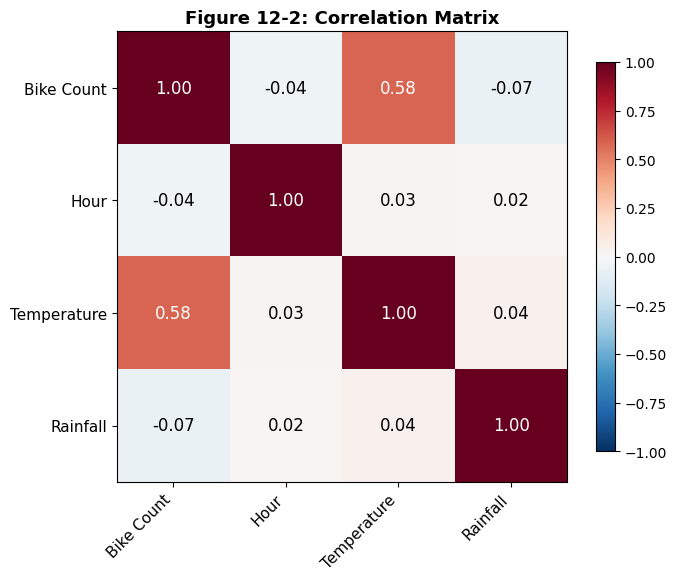


Correlation matrix (numerical values):
                   Rented Bike Count   Hour  Temperature(C)  Rainfall(mm)
Rented Bike Count              1.000 -0.043           0.582        -0.070
Hour                          -0.043  1.000           0.030         0.017
Temperature(C)                 0.582  0.030           1.000         0.044
Rainfall(mm)                  -0.070  0.017           0.044         1.000


In [14]:
# Select four variables for the correlation analysis
corr_vars = data[['Rented Bike Count', 'Hour', 'Temperature(C)', 'Rainfall(mm)']]
corr_matrix = corr_vars.corr()

fig, ax = plt.subplots(1, 1, figsize=(7, 6))
im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, shrink=0.8)

# Labels
labels = ['Bike Count', 'Hour', 'Temperature', 'Rainfall']
ax.set_xticks(range(4))
ax.set_yticks(range(4))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=11)
ax.set_yticklabels(labels, fontsize=11)

# Annotate with correlation values
for i in range(4):
    for j in range(4):
        color = 'white' if abs(corr_matrix.values[i,j]) > 0.5 else 'black'
        ax.text(j, i, f'{corr_matrix.values[i,j]:.2f}',
                ha='center', va='center', fontsize=12, color=color)

ax.set_title('Figure 12-2: Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCorrelation matrix (numerical values):")
print(corr_matrix.round(3).to_string())

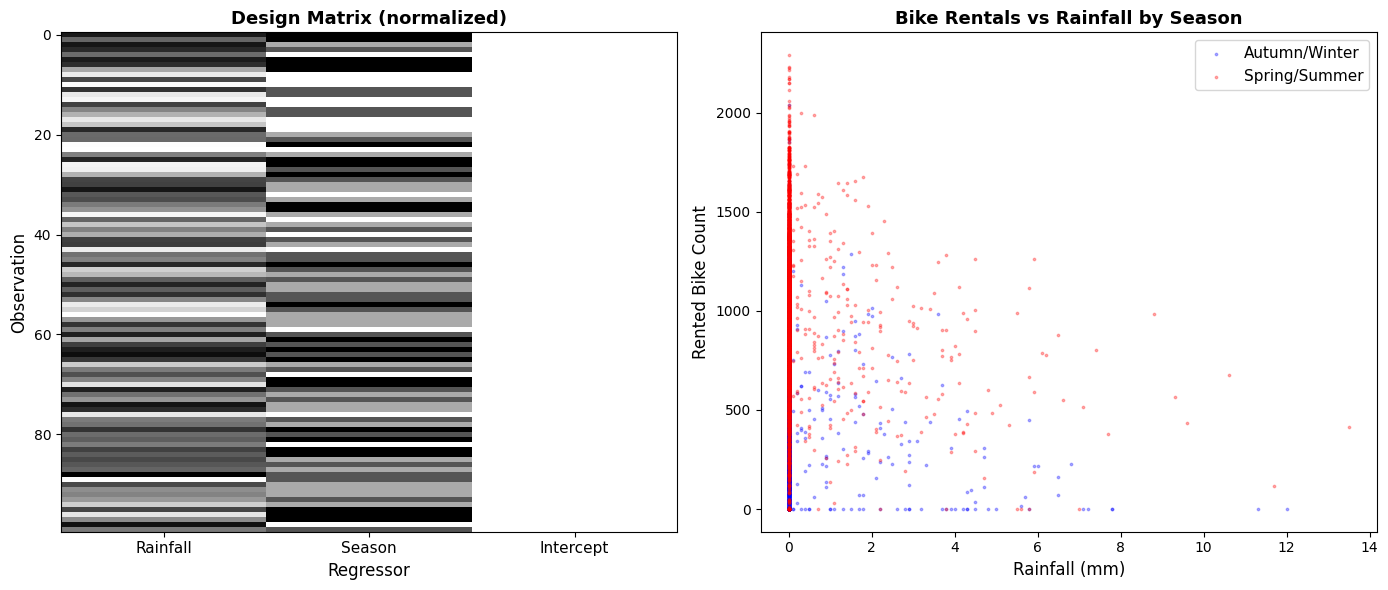

Figure 12-3: Design matrix (left) and data scatter (right).


In [15]:
# Figure 12-3: Design matrix visualization + scatter by season

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Design matrix as an image
# Normalize columns for better visualization
desmat_norm = desmat.copy()
for col in range(desmat.shape[1]):
    col_range = desmat_norm[:, col].max() - desmat_norm[:, col].min()
    if col_range > 0:
        desmat_norm[:, col] = (desmat_norm[:, col] - desmat_norm[:, col].min()) / col_range

axes[0].imshow(desmat_norm, aspect='auto', cmap='gray', interpolation='nearest')
axes[0].set_xlabel('Regressor', fontsize=12)
axes[0].set_ylabel('Observation', fontsize=12)
axes[0].set_xticks([0, 1, 2])
axes[0].set_xticklabels(['Rainfall', 'Season', 'Intercept'], fontsize=11)
axes[0].set_title('Design Matrix (normalized)', fontsize=13, fontweight='bold')

# Right: Scatter plot of rainfall vs bike count, colored by season
autumn_winter = data['SeasonBinary'] == 0
spring_summer = data['SeasonBinary'] == 1

axes[1].scatter(data.loc[autumn_winter, 'Rainfall(mm)'],
               data.loc[autumn_winter, 'Rented Bike Count'],
               s=3, alpha=0.3, c='blue', label='Autumn/Winter')
axes[1].scatter(data.loc[spring_summer, 'Rainfall(mm)'],
               data.loc[spring_summer, 'Rented Bike Count'],
               s=3, alpha=0.3, c='red', label='Spring/Summer')
axes[1].set_xlabel('Rainfall (mm)', fontsize=12)
axes[1].set_ylabel('Rented Bike Count', fontsize=12)
axes[1].set_title('Bike Rentals vs Rainfall by Season', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()
print("Figure 12-3: Design matrix (left) and data scatter (right).")

In [16]:
# Demonstrating multicollinearity

# Create a design matrix where column 3 = column 1 + column 2
np.random.seed(42)
n = 100

X_good = np.column_stack([
    np.random.randn(n),        # Feature 1
    np.random.randn(n),        # Feature 2
    np.ones(n)                 # Intercept
])

X_bad = np.column_stack([
    np.random.randn(n),        # Feature 1
    np.random.randn(n),        # Feature 2
    np.ones(n)                 # Intercept
])
# Make column 2 a copy of column 0 (perfect multicollinearity)
X_bad[:, 1] = X_bad[:, 0]

# Check ranks
print("GOOD design matrix:")
print(f"  Shape: {X_good.shape}")
print(f"  Rank:  {np.linalg.matrix_rank(X_good)}")
print(f"  X'X condition number: {np.linalg.cond(X_good.T @ X_good):.1f}")

print()
print("BAD design matrix (with multicollinearity):")
print(f"  Shape: {X_bad.shape}")
print(f"  Rank:  {np.linalg.matrix_rank(X_bad)}")
print(f"  X'X condition number: {np.linalg.cond(X_bad.T @ X_bad):.1e}")

# Try to solve
y_demo = np.random.randn(n)
print()
print("Solving least squares on GOOD matrix:")
beta_good = np.linalg.lstsq(X_good, y_demo, rcond=None)
print(f"  Solution: {beta_good[0].round(4)}")

print()
print("Solving least squares on BAD matrix:")
beta_bad = np.linalg.lstsq(X_bad, y_demo, rcond=None)
print(f"  Solution: {beta_bad[0].round(4)}")
print("  Note: np.linalg.lstsq finds A solution (min-norm),")
print("  but the solution is NOT unique -- there are infinitely many.")

GOOD design matrix:
  Shape: (100, 3)
  Rank:  3
  X'X condition number: 1.5

BAD design matrix (with multicollinearity):
  Shape: (100, 3)
  Rank:  2
  X'X condition number: 8.0e+15

Solving least squares on GOOD matrix:
  Solution: [-0.1315  0.1957 -0.074 ]

Solving least squares on BAD matrix:
  Solution: [-0.052  -0.052  -0.0493]
  Note: np.linalg.lstsq finds A solution (min-norm),
  but the solution is NOT unique -- there are infinitely many.


**Predicting Bike Rentals Based on Weather**

I’m a big fan of bicycles and a big fan of bibimbap (a Korean dish made with rice
and veggies or meat). Therefore, I was happy to find a publicly available dataset about
bike rentals in Seoul.1

The dataset contains nearly nine thousand observations of
data about the number of bikes that were rented in the city and variables about the
weather including temperature, humidity, rainfall, windspeed, and so on.

time exploring it. In this chapter, I will focus on building relatively simple regression
models to predict bike rental counts based on a few features.

Although this is a book on linear algebra and not statistics, it is still important to
inspect the data carefully before applying and interpreting statistical analyses. The
online code has more details about importing and inspecting the data using the
pandas library. Figure 12-1 shows the data from bike count rentals (the dependent
variable) and rainfall (one of the independent variables).

The beta values for rainfall and season are, respectively, −80 and 369. These numbers
indicate that there are fewer bike rentals when it rains and that there are more bike
rentals in the spring/summer compared to autumn/winter.

**Regression Table Using statsmodels**

Without getting too deep into the statistics, I want to show you how to create
a regression table using the statsmodels library. This library works with pandas
dataframes instead of NumPy arrays. The following code shows how to set up and
compute the regression model (OLS stands for ordinary least squares):

**Multicollinearity**

If you’ve taken a statistics course, you might have heard of the term multicollinearity.
The Wikipedia definition is “one predictor variable in a multiple regression model
can be linearly predicted from the others with a substantial degree of accuracy.”2
This means that there are linear dependencies in the design matrix. In the parlance of
linear algebra, multicollinearity is just a fancy term for linear dependence, which is the
same thing as saying that the design matrix is reduced-rank or that it is singular.

**Regularization**

Regularization is an umbrella term that refers to various ways of modifying a statis‐
tical model, with the goal of improving numerical stability, transforming singular
or ill-conditioned matrices to full-rank (and thus invertible), or improving generaliz‐
ability by reducing overfitting. There are several forms of regularization depending
on the nature of the problem and the goal of regularizing; some specific techniques
you might have heard of include Ridge (a.k.a. L2), Lasso (a.k.a. L1), Tikhonov, and
shrinkage.

**Polynomial Regression**

A polynomial regression is like a normal regression but the independent variables are
the x-axis values raised to higher powers. That is, each column i of the design matrix
is defined as x
i
, where x is typically time or space but can be other variables such as
medication dosage or population.

Other than the special design matrix, a polynomial regression is exactly the same
as any other regression: use the left-inverse (or more computationally stable alter‐
natives) to obtain the set of coefficients such that the weighted combination of
regressors (i.e., the predicted data) best matches the observed data.
Polynomial regressions are used in curve fitting and in approximating nonlinear

functions. Applications include time series modeling, population dynamics, dose-
response functions in medical research, and physical stresses on structural support

beams. Polynomials can also be expressed in 2D, which are used to model spatial
structure such as earthquake propagation and brain activity.

**Grid Search to Find Model Parameters**

Least squares via the left-inverse is a brilliant way to fit models to data. Least squares
is accurate, fast, and deterministic (meaning that each time you rerun the code, you’ll
get the same result). But it works only for linear model fitting, and not all models can
be fit using linear methods.
In this section, I will introduce you to another optimization method used to identify
model parameters, known as grid search. A grid search works by sampling the param‐
eter space, computing the model fit to the data with each parameter value, and then
selecting the parameter value that gave the best model fit.
As a simple example, let’s take the function y = x
2
. We want to find the minimum of
that function. Of course, we already know that the minimum is at x = 0; this helps us
understand and evaluate the results of the grid search method.
In the grid search technique, we start with a predefined set of x values to test. Let’s
use the set (−2, −1, 0, 1, 2). That’s our “grid.” Then we compute the function at each of
those grid values to obtain y = (4, 1, 0, 1, 4). And we find that the minimum y occurs
when x = 0. In this case, the grid-based solution is the same as the true solution.